### download 2022 aggregated US census tract-level results which Cindy (EPA subcontractor) sent me

https://www.epa.gov/rsei/ways-get-rsei-results#microdata 

documentation: https://www.epa.gov/system/files/documents/2024-08/rsei-documentation-geographic-microdata-august-2024.pdf

old versions can be found here: https://github.com/ianamunoz/tri_map/tree/master/data in Environmental Research Letters: Linking 'toxic outliers' to environmental justice communities.

https://www.census.gov/geographies/reference-files/time-series/geo/gazetteer-files.2022.html#list-tab-264479560

In [3]:
import os
import numpy as np
from sklearn.cluster import KMeans
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import pandas as pd

In [4]:
path = r"C:\Users\charlott\Dropbox (Personal)\Book_Chapters\Toxic_Pollution_Feminized_Labor"
files = glob.glob(os.path.join(path, "*.csv"))
print(files)
# Score → RSEI Score (toxicity × fate × population)
# ToxConc → toxicity-weighted concentration aka Concentration multiplied by inhalation toxicity weight.

['C:\\Users\\charlott\\Dropbox (Personal)\\Book_Chapters\\Toxic_Pollution_Feminized_Labor\\censusmicrotract2022_2022_aggregated.csv']


In [5]:
file_path = files[0]
df_2022 = pd.read_csv(file_path, compression="gzip")
print(df_2022.head())

# e g 22017022500 is a Census Tract GEOID, always 11 digits like SSCCCTTTTTT
# where the CCC correspond to the county.
# hence : GEOID[:2]   → state FIPS, GEOID[2:5]  → county FIPS, GEOID[5:]   → tract code

print("Loaded file:", file_path)

         GeoID  NumFacs  NumReleases  NumChems      ToxConc        Score  \
0  22017022500       25          191        47   2219.71000  1709.780000   
1  48215022703        6           29        16      1.88755     0.910853   
2  36113070900       24          109        41    904.77600  1321.280000   
3  53011040509       95          453        58   7522.78000  4610.700000   
4   1055000900       53          303        67  12659.20000  6661.690000   

       Pop  CancToxConc  NonCancToxConc  
0     0.00   2199.72000       31.644000  
1  2215.40      1.87604        0.018934  
2  5364.48    869.34500       35.593300  
3  2860.98   7511.23000      275.990000  
4  2613.22   4570.13000     8106.930000  
Loaded file: C:\Users\charlott\Dropbox (Personal)\Book_Chapters\Toxic_Pollution_Feminized_Labor\censusmicrotract2022_2022_aggregated.csv


In [6]:
print(df_2022[['GeoID', 'Pop']].head(3))

         GeoID      Pop
0  22017022500     0.00
1  48215022703  2215.40
2  36113070900  5364.48


for census tracts, land area does not change over time unless there is a boundary revision. we implicitly assume 2022 tract boundaries for all years.

In [7]:
folder = r"C:\Users\charlott\Dropbox (Personal)\Book_Chapters\Toxic_Pollution_Feminized_Labor\2022_Gaz_tracts_national"

file_path = os.path.join(folder, os.listdir(folder)[0])
gazetteer = pd.read_csv(file_path, delimiter='\t')

print(gazetteer.columns)
print(gazetteer['GEOID'].head(5))
gazetteer.rename(columns={'GEOID': 'GeoID'}, inplace=True)

Index(['USPS', 'GEOID', 'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI',
       'INTPTLAT',
       'INTPTLONG                                                                                                                             '],
      dtype='object')
0    1001020100
1    1001020200
2    1001020300
3    1001020400
4    1001020501
Name: GEOID, dtype: int64


In [8]:
df_2022['GeoID'] = df_2022['GeoID'].astype(str)
gazetteer['GeoID'] = gazetteer['GeoID'].astype(str)

overlap = df_2022['GeoID'].isin(gazetteer['GeoID'])
print("Number of matching GeoIDs:", overlap.sum())
print("Number of non-matching GeoIDs:", (~overlap).sum())

print("Example matches:", df_2022.loc[overlap, 'GeoID'].head(10).tolist())
print("Example non-matches:", df_2022.loc[~overlap, 'GeoID'].head(10).tolist())

Number of matching GeoIDs: 83653
Number of non-matching GeoIDs: 1000
Example matches: ['22017022500', '48215022703', '36113070900', '53011040509', '1055000900', '21225950202', '6065041905', '49053270805', '4015950103', '25017356400']
Example non-matches: ['9003487400', '9003503700', '9005260200', '9003514200', '9003416200', '9001045300', '9003410102', '9009166004', '9001072500', '9003473601']


In [9]:
gaz_cols_to_add = [col for col in gazetteer.columns if col not in df_2022.columns and col != 'GeoID']
merged_df = df_2022.merge(gazetteer[['GeoID'] + gaz_cols_to_add], on='GeoID', how='left')
print(merged_df.shape)
print(merged_df.columns)

(84653, 16)
Index(['GeoID', 'NumFacs', 'NumReleases', 'NumChems', 'ToxConc', 'Score',
       'Pop', 'CancToxConc', 'NonCancToxConc', 'USPS', 'ALAND', 'AWATER',
       'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT',
       'INTPTLONG                                                                                                                             '],
      dtype='object')


As of 2022, there are 3,144 counties and county-equivalents in the 50 U.S. states and the District of Columbia

In [10]:
# Ensure GeoID is string
merged_df['GeoID'] = merged_df['GeoID'].astype(str)

# Pad GeoID to 11 digits with leading zeros
merged_df['GeoID'] = merged_df['GeoID'].str.zfill(11)

# Extract FIPS codes
merged_df['State_fips'] = merged_df['GeoID'].str[:2]
merged_df['County_fips'] = merged_df['GeoID'].str[:5]

# Verify
print(merged_df[['GeoID', 'State_fips', 'County_fips']].head(10))

         GeoID State_fips County_fips
0  22017022500         22       22017
1  48215022703         48       48215
2  36113070900         36       36113
3  53011040509         53       53011
4  01055000900         01       01055
5  21225950202         21       21225
6  06065041905         06       06065
7  49053270805         49       49053
8  04015950103         04       04015
9  25017356400         25       25017


In [11]:
distinct_states = merged_df['State_fips'].nunique()
print("Number of distinct state FIPS codes:", distinct_states)
print("Distinct state FIPS codes:", merged_df['State_fips'].value_counts().sort_values().index.tolist())

Number of distinct state FIPS codes: 56
Distinct state FIPS codes: ['60', '69', '78', '66', '56', '02', '50', '11', '38', '46', '44', '10', '30', '33', '23', '15', '16', '31', '54', '35', '49', '32', '05', '20', '28', '09', '19', '72', '41', '40', '21', '45', '22', '08', '01', '24', '27', '55', '25', '29', '18', '04', '47', '53', '34', '51', '37', '13', '26', '39', '17', '42', '12', '36', '48', '06']


In [12]:
ny_counties = merged_df[merged_df['County_fips'].str.startswith("36")]['County_fips']

num_ny_counties = ny_counties.nunique()
print("Number of distinct counties in New York (FIPS 36):", num_ny_counties)

print("County FIPS codes in NY:", ny_counties.unique())
# this was just a check - all good 

Number of distinct counties in New York (FIPS 36): 62
County FIPS codes in NY: ['36113' '36067' '36103' '36059' '36081' '36031' '36047' '36085' '36119'
 '36005' '36029' '36121' '36071' '36075' '36007' '36061' '36117' '36055'
 '36065' '36001' '36037' '36083' '36017' '36035' '36003' '36011' '36115'
 '36019' '36073' '36051' '36069' '36109' '36101' '36063' '36091' '36027'
 '36023' '36043' '36105' '36045' '36021' '36053' '36009' '36111' '36025'
 '36057' '36013' '36097' '36087' '36077' '36093' '36015' '36039' '36107'
 '36033' '36089' '36095' '36099' '36079' '36123' '36041' '36049']


In [13]:
ny_counties = merged_df[merged_df['County_fips'].str.startswith("01")]['County_fips']

num_ny_counties = ny_counties.nunique()
print("Number of distinct counties in Alabama (FIPS 01):", num_ny_counties)

print("County FIPS codes in Alabama:", ny_counties.unique())
# this was just a check - all good 

Number of distinct counties in Alabama (FIPS 01): 67
County FIPS codes in Alabama: ['01055' '01101' '01035' '01073' '01025' '01031' '01089' '01107' '01133'
 '01125' '01015' '01127' '01009' '01039' '01069' '01117' '01003' '01121'
 '01067' '01011' '01081' '01115' '01045' '01113' '01033' '01043' '01123'
 '01047' '01109' '01007' '01097' '01057' '01103' '01051' '01037' '01017'
 '01071' '01083' '01077' '01091' '01111' '01013' '01021' '01061' '01093'
 '01131' '01049' '01119' '01065' '01059' '01095' '01005' '01099' '01087'
 '01079' '01085' '01129' '01029' '01041' '01001' '01105' '01063' '01023'
 '01053' '01019' '01027' '01075']


In [14]:
ny_counties = merged_df[merged_df['County_fips'].str.startswith("04")]['County_fips']

num_ny_counties = ny_counties.nunique()
print("Number of distinct counties in Arizona (FIPS 04):", num_ny_counties)

print("County FIPS codes in Arizona:", ny_counties.unique())
# this was just a check - all good 

Number of distinct counties in Arizona (FIPS 04): 15
County FIPS codes in Arizona: ['04015' '04013' '04017' '04025' '04019' '04009' '04027' '04021' '04005'
 '04003' '04001' '04012' '04007' '04023' '04011']


In [15]:
# Calculate total area in square miles
merged_df['TOTAL_AREA_SQMI'] = merged_df['ALAND_SQMI'] + merged_df['AWATER_SQMI']
print(merged_df[['GeoID', 'ALAND_SQMI', 'AWATER_SQMI', 'TOTAL_AREA_SQMI']].head())

         GeoID  ALAND_SQMI  AWATER_SQMI  TOTAL_AREA_SQMI
0  22017022500       1.043        0.000            1.043
1  48215022703       0.683        0.000            0.683
2  36113070900      15.715        0.569           16.284
3  53011040509       0.744        0.316            1.060
4  01055000900       4.607        0.282            4.889


In [16]:
print(merged_df.columns)

Index(['GeoID', 'NumFacs', 'NumReleases', 'NumChems', 'ToxConc', 'Score',
       'Pop', 'CancToxConc', 'NonCancToxConc', 'USPS', 'ALAND', 'AWATER',
       'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT',
       'INTPTLONG                                                                                                                             ',
       'State_fips', 'County_fips', 'TOTAL_AREA_SQMI'],
      dtype='object')


In [19]:
tract_df = merged_df.copy()

# Rename for consistency with county output schema
tract_df = tract_df.rename(columns={
    'CancToxConc':    'CancToxConc_mean',     # already tract-level, no weighting needed
    'NonCancToxConc': 'NonCancToxConc_mean',
    'ToxConc':        'ToxConc_mean',
})

# Totals: at tract level these are identical to the mean values
# but we keep them for schema consistency with the county table
tract_df['Score_total']        = tract_df['Score']
tract_df['CancToxConc_total']  = tract_df['CancToxConc_mean']
tract_df['NonCancToxConc_total'] = tract_df['NonCancToxConc_mean']
tract_df['ToxConc_total']      = tract_df['ToxConc_mean']

# Select and reorder to match county output schema
tract_level = tract_df[[
    'GeoID',            # tract identifier — add this
    'County_fips',      # so you can still join to county table if needed
    'State_fips',
    'Pop',
    'NumFacs',
    'NumReleases',
    'NumChems',
    'CancToxConc_mean',
    'NonCancToxConc_mean',
    'ToxConc_mean',
    'Score_total',
    'CancToxConc_total',
    'NonCancToxConc_total',
    'ToxConc_total',
    'TOTAL_AREA_SQMI',
]].copy()

In [21]:
tract_level['ToxConc_per_capita']   = tract_level['ToxConc_total'] / tract_level['Pop']
tract_level['Score_per_sqmi']       = tract_level['Score_total']   / tract_level['TOTAL_AREA_SQMI']

In [22]:
print(tract_level.shape)

(84653, 17)


In [23]:
print(tract_level['State_fips'].unique()[:56])

['22' '48' '36' '53' '01' '21' '06' '49' '04' '25' '08' '54' '35' '51'
 '37' '41' '18' '13' '12' '39' '26' '42' '45' '47' '28' '05' '27' '55'
 '34' '44' '09' '56' '29' '46' '11' '20' '10' '32' '17' '72' '40' '38'
 '16' '24' '19' '15' '33' '50' '23' '30' '31' '66' '02' '78' '69' '60']


In [24]:
# select GeoIDs starting with Fresno County: 06019
fresno_geoids = tract_level[tract_level['GeoID'].astype(str).str.startswith('06019')]

# check result
print(fresno_geoids[['County_fips', 'Pop']].head(15))

     County_fips      Pop
660        06019  3806.92
1063       06019  3880.68
1514       06019  4357.20
1791       06019  5785.10
1920       06019  5095.78
2045       06019  4326.26
2855       06019  5783.46
2876       06019  8079.95
3046       06019  5902.71
3101       06019  3911.63
3116       06019  3115.92
4528       06019  3040.25
4957       06019  5897.10
5060       06019  8975.70
6383       06019  4214.64


Now add variable on county names from external source 

In [25]:
import pandas as pd
import requests

# Download
url = "https://transition.fcc.gov/oet/info/maps/census/fips/fips.txt"
r = requests.get(url)
r.raise_for_status()
text = r.text

lines = text.splitlines()
data = []
start = False

for line in lines:
    if not line.strip():
        continue  # skip empty lines
    
    tokens = line.strip().split()  # split by any whitespace
    if len(tokens) < 2:
        continue  # skip malformed lines
    
    fips_candidate = tokens[0]
    
    # Start collecting from the first FIPS code "01001"
    if fips_candidate == "01001":
        start = True
    
    if start:
        fips = fips_candidate
        name = " ".join(tokens[1:])  # everything after FIPS = county name
        data.append((fips, name))

# Convert to DataFrame
fips_df = pd.DataFrame(data, columns=['County_fips', 'CountyName'])

# Check
print(f"Number of rows: {len(fips_df)}")
print(fips_df.head(10))

Number of rows: 3194
  County_fips       CountyName
0       01001   Autauga County
1       01003   Baldwin County
2       01005   Barbour County
3       01007      Bibb County
4       01009    Blount County
5       01011   Bullock County
6       01013    Butler County
7       01015   Calhoun County
8       01017  Chambers County
9       01019  Cherokee County


In [ ]:
# Make a copy to avoid modifying the original
tract_clean = tract_level.copy()

# Drop existing CountyName to avoid duplicate column error
if 'CountyName' in tract_clean.columns:
    tract_clean = tract_clean.drop(columns=['CountyName'])

# Merge county names onto tracts via County_fips
merged_df = tract_clean.merge(
    fips_df,
    on='County_fips',
    how='left'
)

num_matched = merged_df['CountyName'].notna().sum()
num_unmatched = merged_df['CountyName'].isna().sum()
print(f"Matched tracts: {num_matched}")
print(f"Unmatched tracts: {num_unmatched}")
unmatched_examples = merged_df.loc[merged_df['CountyName'].isna(), 'County_fips'].head(5)
print("Unmatched County_fips examples:", unmatched_examples.tolist())

In [29]:
# -----------------------------
# Codebook for tract_level
# -----------------------------
codebook = {
    'GeoID':               'Census tract identifier (11-digit FIPS)',
    'County_fips':         'FIPS code of the county the tract belongs to',
    'State_fips':          'FIPS code of the state',
    'Pop':                 'Total population in the census tract (2022 data)',
    'NumFacs':             'Total number of facilities in the census tract',
    'NumReleases':         'Total number of chemical releases in the census tract',
    'NumChems':            'Total number of different chemicals released in the census tract',
    'CancToxConc_mean':    'Cancer toxicity concentration at tract level (µg/m3 × inhalation toxicity weight)',
    'NonCancToxConc_mean': 'Non-cancer toxicity concentration at tract level (µg/m3 × inhalation toxicity weight)',
    'ToxConc_mean':        'Total toxicity concentration at tract level (µg/m3 × inhalation toxicity weight)',
    'Score_total':         'Risk score for the tract (dose × toxicity weight × potentially exposed population)',
    'CancToxConc_total':   'Same as CancToxConc_mean at tract level (no further aggregation)',
    'NonCancToxConc_total':'Same as NonCancToxConc_mean at tract level (no further aggregation)',
    'ToxConc_total':       'Same as ToxConc_mean at tract level (no further aggregation)',
    'TOTAL_AREA_SQMI':     'Total area of the census tract in square miles (2022 data)',
    'ToxConc_per_capita':  'ToxConc_total divided by tract population',
    'Score_per_sqmi':      'Score_total divided by tract area in square miles',
}

codebook_df = pd.DataFrame({
    'Variable': list(codebook.keys()),
    'Definition': list(codebook.values())
})

cols_to_drop = ['CountyName_x', 'StateAbbr', 'CountyName_y']
merged_df = merged_df.drop(columns=[c for c in cols_to_drop if c in merged_df.columns])
merged_df = merged_df.drop_duplicates()

# Sort hierarchically: state → county → tract
merged_df = merged_df.sort_values(
    ['State_fips', 'County_fips', 'GeoID'],
    ascending=True
).reset_index(drop=True)

# Export tract data + codebook to Excel
with pd.ExcelWriter("pollution_tract_22.xlsx") as writer:
    merged_df.to_excel(writer, sheet_name="Tract_Level", index=False)
    codebook_df.to_excel(writer, sheet_name="Codebook", index=False)

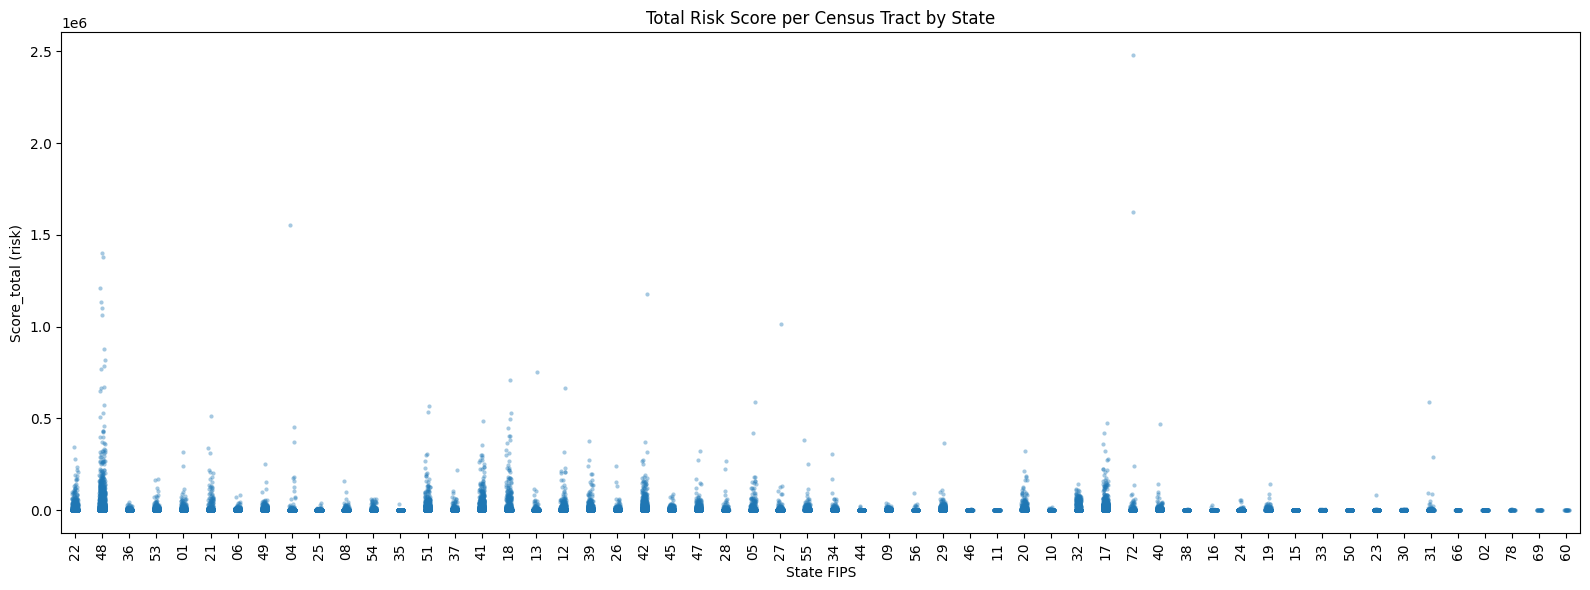

In [30]:
plt.figure(figsize=(16,6))
sns.stripplot(
    x='State_fips',
    y='Score_total',
    data=tract_level,
    jitter=True,
    alpha=0.4,
    size=3
)
plt.title("Total Risk Score per Census Tract by State")
plt.xlabel("State FIPS")
plt.ylabel("Score_total (risk)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\charlott\AppData\Local\Temp\ipykernel_768\3247007246.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


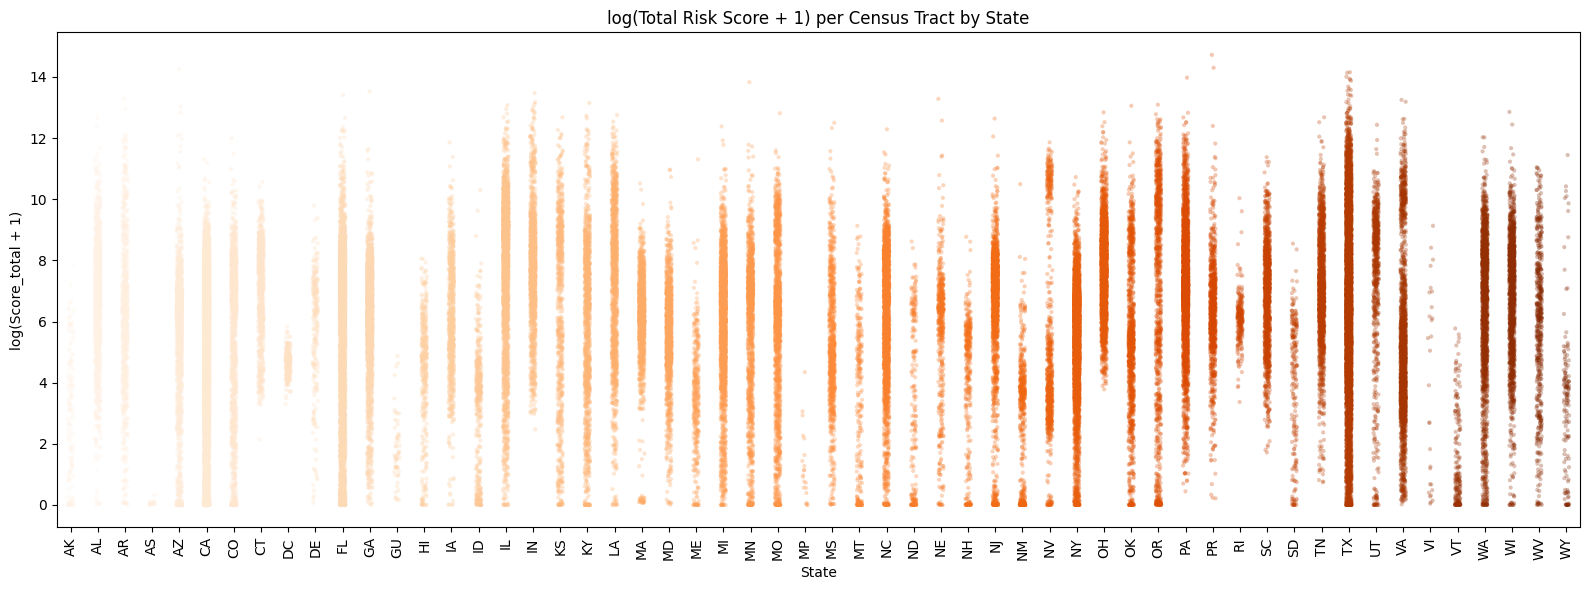

In [31]:
import numpy as np

state_fips_to_abbr = {
    '01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA',
    '08': 'CO', '09': 'CT', '10': 'DE', '11': 'DC', '12': 'FL',
    '13': 'GA', '15': 'HI', '16': 'ID', '17': 'IL', '18': 'IN',
    '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME',
    '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS',
    '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH',
    '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND',
    '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI',
    '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT',
    '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI',
    '56': 'WY', '60': 'AS', '66': 'GU', '69': 'MP', '72': 'PR', '78': 'VI'
}

tract_plot = tract_level.copy()
tract_plot['log_Score_total'] = np.log1p(tract_plot['Score_total'])
tract_plot['State'] = tract_plot['State_fips'].map(state_fips_to_abbr).fillna(tract_plot['State_fips'])

plt.figure(figsize=(16,6))
sns.stripplot(
    x='State',
    y='log_Score_total',
    data=tract_plot,
    order=sorted(tract_plot['State'].unique()),
    jitter=True,
    alpha=0.3,
    size=3,
    palette='Oranges'
)
plt.title("log(Total Risk Score + 1) per Census Tract by State")
plt.xlabel("State")
plt.ylabel("log(Score_total + 1)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Even on a log scale, toxic risk scores vary considerably across and within states: most tracts cluster near the bottom of the distribution, but a handful of tracts in industrially intensive states — particularly in the South and Midwest (e.g., TX, LA, IN, OH) — stand out as extreme high-risk outliers. The wide within-state spread visible in larger states reflects the uneven geographic concentration of polluting facilities, where a single tract near an industrial complex can drive the state's upper tail. This pattern suggests that state-level or county-level averages obscure sharp local inequalities in toxic burden at the neighborhood level.

In [ ]:
# At tract level, _mean and _total are identical (see cell 18).
# We plot the unique measures: CancToxConc, NonCancToxConc, ToxConc, and Score.
plot_cols = ['CancToxConc_mean', 'NonCancToxConc_mean', 'ToxConc_mean', 'Score_total']
short_labels = ['CancToxConc', 'NonCancToxConc', 'ToxConc', 'Score']

tract_log = tract_level.copy()
for col in plot_cols:
    tract_log[col] = np.log1p(tract_log[col])

melt_df = tract_log.melt(
    id_vars=['GeoID', 'State_fips'],
    value_vars=plot_cols,
    var_name='Variable',
    value_name='Value'
)
melt_df['Measure'] = melt_df['Variable'].map(dict(zip(plot_cols, short_labels)))

plt.figure(figsize=(12, 6))
sns.violinplot(
    x='Measure',
    y='Value',
    data=melt_df,
    inner='quartile',
    palette='Set2'
)
plt.title("Distribution of log(Toxicity Measures) across Census Tracts")
plt.ylabel("log(value + 1)")
plt.xlabel("Measure")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# At tract level _mean == _total by construction, so we correlate the 4 distinct measures
plot_cols  = ['CancToxConc_mean', 'NonCancToxConc_mean', 'ToxConc_mean', 'Score_total']
short_labels = ['CancToxConc', 'NonCancToxConc', 'ToxConc', 'Score']

log_data = np.log1p(tract_level[plot_cols].rename(columns=dict(zip(plot_cols, short_labels))))
corr = log_data.corr()

plt.style.use('seaborn-v0_8-white')
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0.7, vmax=1.0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r (log scale)'}
)

ax.set_title('Pairwise Correlations across Census Tracts (log scale)',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.show()

**Heatmap summary.** Among the *mean* measures, cancer and total toxicity concentrations are nearly interchangeable (r = 0.98), while non-cancer toxicity is more loosely related to both (r = 0.74 and r = 0.82). This suggests that cancer-risk chemicals dominate the overall mean exposure signal, with non-cancer pathways capturing a somewhat distinct dimension. Among the *total* measures, all four variables are highly correlated (r ≥ 0.85), with `ToxConc_total` and `Score_total` being almost perfectly aligned (r = 0.99), indicating that once you aggregate across all chemicals and weight by population, cancer and non-cancer risks converge. The notably weaker correlation of non-cancer with cancer in the mean measures (0.74) versus the total measures (0.85) suggests that county size partially smooths out differences in chemical composition.

In [ ]:
cap = tract_level['Score_total'].quantile(0.98)
score_trimmed = tract_level['Score_total'][tract_level['Score_total'] <= cap].dropna()
score_log = np.log1p(score_trimmed)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

score_log.plot.kde(ax=ax, color='#E07B39', linewidth=2.5)
ax.fill_between(
    ax.lines[0].get_xdata(),
    ax.lines[0].get_ydata(),
    alpha=0.15, color='#E07B39'
)

ax.set_xlabel('log(Score_total + 1)', fontsize=12, labelpad=10)
ax.set_ylabel('Density', fontsize=12, labelpad=10)
ax.set_title('Distribution of log(Total Risk Score) across Census Tracts',
             fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

skew_log = score_log.skew()
print(f"Skewness after log transform: {skew_log:.2f}")
if abs(skew_log) <= 0.5:
    print("The log-transformed distribution is approximately symmetric.")
elif skew_log > 0.5:
    print(f"Still right-skewed after log transform (skewness = {skew_log:.2f}).")
else:
    print(f"Left-skewed after log transform (skewness = {skew_log:.2f}).")

In [ ]:
print("Top 5% tracts by Score_total:\n")

threshold = merged_df['Score_total'].quantile(0.95)
top_tracts = merged_df[merged_df['Score_total'] >= threshold].copy()
top_tracts['StateAbbr'] = top_tracts['State_fips'].map(state_fips_to_abbr)
top_tracts['Label'] = top_tracts.apply(
    lambda r: f"{r['CountyName']}, {r['StateAbbr']}" if pd.notna(r['CountyName'])
              else f"FIPS {r['County_fips']}, {r['StateAbbr']}",
    axis=1
)
top_tracts_sorted = top_tracts.sort_values('Score_total', ascending=False)

for _, row in top_tracts_sorted.iterrows():
    print(f"  Tract {row['GeoID']}  ({row['Label']:40s})  Score = {row['Score_total']:,.0f}")

**Top 5% counties by total risk score — interpretation.**

Three macro-geographic clusters stand out:

1. **Texas Gulf Coast / petrochemical corridor.** Harris (Houston), Jefferson (Beaumont–Port Arthur), Galveston, Orange, Brazoria, and Montgomery counties are all within or adjacent to the Houston Ship Channel, the densest concentration of oil refineries, chemical plants, and plastics manufacturing in the United States. Harris County alone scores nearly twice as high as the second-ranked county (Cook, IL), reflecting both the sheer scale of industrial activity and the large exposed population in the Houston metro.

2. **Louisiana "Cancer Alley."** East Baton Rouge, Calcasieu (Lake Charles), Ascension, St. John the Baptist, St. Charles, and Jefferson parishes map directly onto the stretch of the Mississippi River between Baton Rouge and New Orleans — a corridor long documented for its exceptional concentration of petrochemical and chlorine-chemistry facilities, and disproportionate exposure of low-income Black communities.

3. **Industrial Midwest.** Indiana (Vanderburgh, Warrick, Lake, Elkhart), Ohio (Hamilton, Cuyahoga, Butler, Lorain, Erie, Allen), and Pennsylvania (Lancaster, Berks, York, Chester) reflect the legacy steel, aluminum, automotive, and chemical manufacturing belt. Several of these are relatively small counties (e.g., Warrick IN — home to a major Alcoa aluminum smelter; Henderson KY; Platte NE) whose high scores are driven by a single large facility rather than a broad industrial base, making them cases where *pollution intensity* rather than *population size* drives the ranking.

**Population size and score.** The top-ranked counties (Harris TX, Cook IL, Los Angeles CA, King WA) are among the most populous in the country, so their high scores partly reflect the number of people exposed rather than unusually severe per-capita contamination. Mid-list counties like Gila AZ (copper mining), Newton GA (heavy manufacturing), Wyandotte KS, and Goodhue MN are far smaller and likely host one or two dominant polluters — a pattern worth distinguishing analytically from large-city exposure. Bayamón PR (FIPS 72011) stands out as the only territory in the list, driven by pharmaceutical manufacturing concentrated on the island (remove islands?)

In [ ]:
print("Top 2% tracts by ToxConc_total:\n")

threshold = merged_df['ToxConc_total'].quantile(0.98)
top_tracts = merged_df[merged_df['ToxConc_total'] >= threshold].copy()
top_tracts['StateAbbr'] = top_tracts['State_fips'].map(state_fips_to_abbr)
top_tracts['Label'] = top_tracts.apply(
    lambda r: f"{r['CountyName']}, {r['StateAbbr']}" if pd.notna(r['CountyName'])
              else f"FIPS {r['County_fips']}, {r['StateAbbr']}",
    axis=1
)
top_tracts_sorted = top_tracts.sort_values('ToxConc_total', ascending=False)

for _, row in top_tracts_sorted.iterrows():
    print(f"  Tract {row['GeoID']}  ({row['Label']:40s})  ToxConc_total = {row['ToxConc_total']:,.0f}")

**Score_total vs. ToxConc_total**
The two rankings overlap substantially but diverge in revealing ways. `Score_total` weights toxicity by the number of people potentially exposed, so it is a measure of *population burden*. `ToxConc_total` is the raw sum of toxicity concentrations across a county, irrespective of how many people live there; it is a measure of *industrial intensity*.

**Counties that rise in ToxConc_total (more toxic than their population-weighted score suggests):**
- **Jefferson County, TX** (Beaumont–Port Arthur) jumps from rank 4 to rank 3, and the gap with Harris County nearly halves. This confirms it as one of the most industrially concentrated petrochemical zones in the country, not just large in population.
- **Wyandotte County, KS**, **Vanderburgh County, IN**, and **Warrick County, IN** all hold or improve their positions, suggesting high raw chemical loads relative to their population — likely driven by a small number of very large facilities.
- **Jackson County, MO**, **Tulsa County, OK**, **Franklin County, OH**, and **Milwaukee County, WI** appear in the ToxConc_total top 2% but are lower or absent in the Score_total top: high industrial output, moderate population.

**Counties that fall in ToxConc_total (their Score_total rank is inflated by population size):**
- **Lancaster County, PA** drops from rank 5 to rank 10, and **Washoe County, NV** from rank 6 to rank 11. Both are sizable counties where a large exposed population amplifies the score beyond what their raw industrial footprint would warrant.
- **Washington County, AR** (#18 in Score_total) disappears entirely from ToxConc_total top 2% — its ranking is largely a function of population growth (it is the fast-growing Fayetteville–Springdale metro), not exceptional pollution intensity.
- **Salt Lake County, UT** similarly drops out, reflecting a large urban population rather than extreme industrial concentration.

**Takeaway.** The choice of measure matters analytically but wont overall change the results much. `Score_total` is the right variable when the research question concerns *how many people are at risk*. `ToxConc_total` (or mean measures) is preferable when the question concerns *where pollution is most intense*, regardless of who lives nearby.

In [ ]:
# where did calhoun country go? aparently did not match when matching with fips, but did so before doing changes. have to find out still.and
